In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import uproot 
from iminuit import Minuit 
from nll import likelihood_building
import pandas as pd
from pandas import plotting as pdplt

ISADORA's CODE

----------------------------------------------

In [2]:
MC = np.load('C:/Users/tryst/All Code/GradSchool/Stats/SMODA_Final_Project_2026/weights.npz')

h_bg_nom = MC["weights_sumBCKG"]
h_sig_nom = MC["weights_sumSGN"]

h_bg_up = np.stack([
    MC["weights_sys1plusBCKG"],
    MC["weights_sys2plusBCKG"],
    MC["weights_sys3plusBCKG"],
    MC["weights_sys4plusBCKG"]
    ])

h_bg_down = np.stack([
    MC["weights_sys1minusBCKG"],
    MC["weights_sys2minusBCKG"],
    MC["weights_sys3minusBCKG"],
    MC["weights_sys4minusBCKG"]
    ])

h_sig_up = np.stack([
    MC["weights_sys1plusSGN"],
    MC["weights_sys2plusSGN"],
    MC["weights_sys3plusSGN"],
    MC["weights_sys4plusSGN"]
    ])

h_sig_down = np.stack([
    MC["weights_sys1minusSGN"],
    MC["weights_sys2minusSGN"],
    MC["weights_sys3minusSGN"],
    MC["weights_sys4minusSGN"]
    ])

bins = np.linspace(60, 160, 21)

In [3]:
f = uproot.open('C:/Users/tryst/All Code/GradSchool/Stats/SMODA_Final_Project_2026/data.root')
data02 = f['events;2'].arrays(['m'], library = "np")['m']

data_binned = np.histogram(data02, bins = bins)[0]

likelihood = likelihood_building(data_binned, h_sig_nom, h_bg_nom, h_sig_up, h_sig_down, h_bg_up, h_bg_down)

m = Minuit(likelihood, theta_1 = 1.0, theta_2 = 1.0, theta_3 = 0.0, theta_4 = 0.0, theta_5 = 0.0, theta_6 = 0.0)

m.migrad()
m.hesse() 

theta_values = np.array(m.values)

In [4]:
print(theta_values)
print(theta_values[0])

[ 9.50752716e-01  2.06444168e+00 -5.05081601e-01 -2.13232303e-01
  1.13875431e-03 -1.96885284e-01]
0.9507527158253255


In [5]:
h_bg_posfit= theta_values[0] * h_bg_nom
h_sig_posfit= theta_values[1] * h_sig_nom 


-----------------------

----------------------------

6.4.1
--------------------

In [6]:
h_total_nom = h_bg_posfit + h_sig_posfit

bins = np.linspace(60, 160, 21)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]


# Get fit results
theta_values = np.array(m.values)
cov_matrix = np.array(m.covariance)

# Extract covariance for θ3-θ6
cov_syst = cov_matrix[2:, 2:]

#data sigma
data_err = np.sqrt(data_binned)


n_bins = len(h_bg_nom)
n_syst = 4

In [7]:
delta_bg_up = h_bg_up - h_bg_nom
delta_bg_down = h_bg_down - h_bg_nom
delta_sig_up = h_sig_up - h_sig_nom
delta_sig_down = h_sig_down - h_sig_nom

In [8]:
#add context for the math

In [9]:
derivatives = np.zeros((n_bins, n_syst))

for j in range(n_syst):
    if theta_values[2+j] >= 0:
        derivatives[:, j] = delta_bg_up[j] + delta_sig_up[j]
    else:
        derivatives[:, j] = -delta_bg_down[j] - delta_sig_down[j]

In [10]:

variance = np.sum(derivatives @ cov_syst * derivatives, axis=1)
system_err = np.sqrt(variance)


In [11]:
print("Covariance matrix:")
print(cov_syst)
print("\nSystematic errors:")
print(system_err)
print("\nNominal predictions (for comparison):")
nominal = theta_values[0] * h_bg_nom + theta_values[1] * h_sig_nom
print(nominal)

Covariance matrix:
[[ 0.13755948  0.03611773  0.20796371 -0.12570444]
 [ 0.03611773  0.03213686  0.14121707 -0.11915154]
 [ 0.20796371  0.14121707  9.48135778 -0.58901455]
 [-0.12570444 -0.11915154 -0.58901455  0.58489603]]

Systematic errors:
[ 6.79806192 11.74601915 19.13117362 27.89244259 34.44896906 40.11532744
 40.49735465 37.94785816 31.78012772 24.77627488 16.99807985 11.35649876
  7.23658634  4.42094345  3.00975818  2.02812959  1.55562458  0.94821298
  0.65767396  0.37412993]

Nominal predictions (for comparison):
[10.36112907 18.16844932 29.76468676 43.43600916 54.09830025 63.08127532
 64.22690259 60.57969958 51.29276172 40.72756429 29.20053273 21.03243517
 14.98886695 10.7367247   8.27363566  6.18896952  4.82161886  3.06325185
  2.08510828  1.18168642]


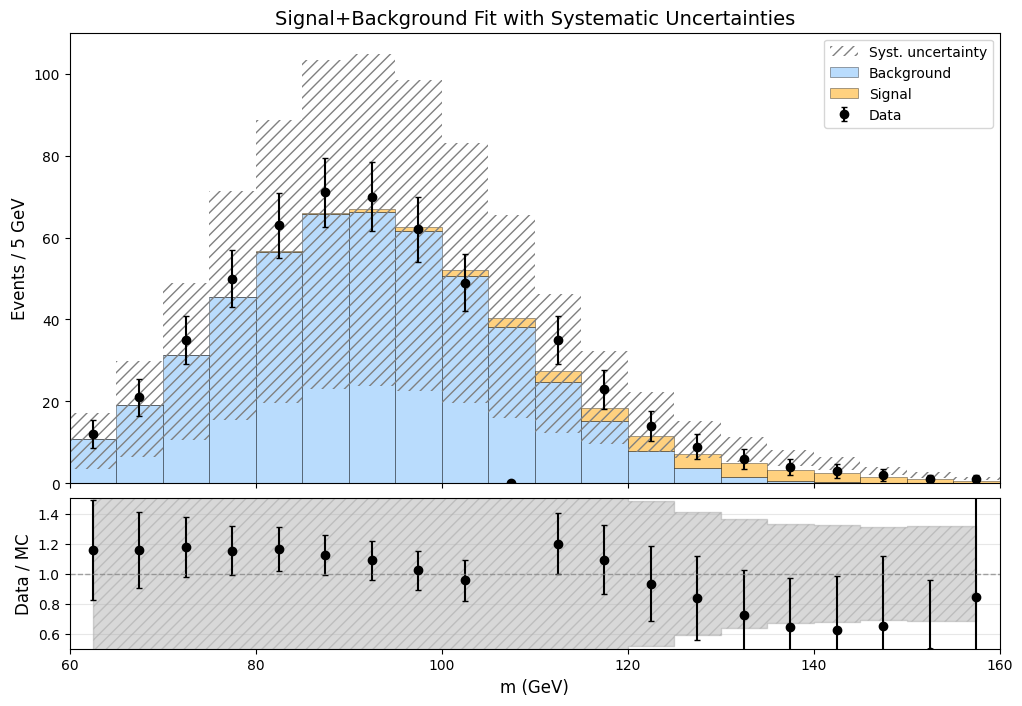

In [12]:
fig, (ax, ax_ratio) = plt.subplots(2, 1, figsize=(12, 8), 
                                    gridspec_kw={'height_ratios': [3, 1], 
                                                'hspace': 0.05})

ax.bar(bin_centers, h_bg_nom, width=bin_width, 
       label='Background', color='xkcd:sky blue', alpha=0.5, 
       edgecolor='black', linewidth=0.5, align='center')

ax.bar(bin_centers, h_sig_nom, width=bin_width, bottom=h_bg_nom,
       label='Signal', color='orange', alpha=0.5, 
       edgecolor='black', linewidth=0.5, align='center')


bin_edges = np.linspace(60, 160, 21)

x_plot = np.repeat(bin_edges, 2)[1:-1]  
y_upper_plot = np.repeat(h_total_nom + system_err, 2)
y_lower_plot = np.repeat(h_total_nom - system_err, 2)

ax.fill_between(x_plot, y_lower_plot, y_upper_plot,
                facecolor='none',  
                hatch='///', 
                edgecolor='gray',  
                linewidth=0,       
                alpha=1.0,         
                label='Syst. uncertainty')

ax.errorbar(bin_centers, data_binned, yerr=data_err, 
            fmt='o', color='black', markersize=6, 
            capsize=2, capthick=1, linewidth=1.5,
            label='Data')

ax.set_ylabel('Events / 5 GeV', fontsize=12)
ax.set_title('Signal+Background Fit with Systematic Uncertainties', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(bins[0], bins[-1])
ax.tick_params(axis='x', which='both', labelbottom=False)



# Ratio plot (Data/MC)
ratio = data_binned / h_total_nom
ratio_err = data_err / h_total_nom

ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, 
                  fmt='o', color='black', markersize=6,
                  capsize=2, capthick=1, linewidth=1.5)

ratio_syst_high = (h_total_nom + system_err) / h_total_nom
ratio_syst_low = (h_total_nom - system_err) / h_total_nom
ax_ratio.fill_between(bin_centers, 
                      ratio_syst_low, ratio_syst_high,
                      step='mid', color='gray', alpha=0.3, hatch='///')

ax_ratio.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax_ratio.set_xlabel('m (GeV)', fontsize=12)
ax_ratio.set_ylabel('Data / MC', fontsize=12)
ax_ratio.set_xlim(bins[0], bins[-1])
ax_ratio.set_ylim(0.5, 1.5)
ax_ratio.grid(True, alpha=0.3, axis='y')

plt.show()


---------

6.4.2
--------------

In [13]:
values = m.values
errors = m.errors

In [14]:
Results = pd.DataFrame({
    'Parameter': m.parameters,
    'Value': [round(m.values[p], 3) for p in m.parameters],
    'Error': [round(m.errors[p], 3) for p in m.parameters]
})

In [15]:
Results['Parameter'] = [rf'$\theta_{i+1}$' for i in range(len(Results))]

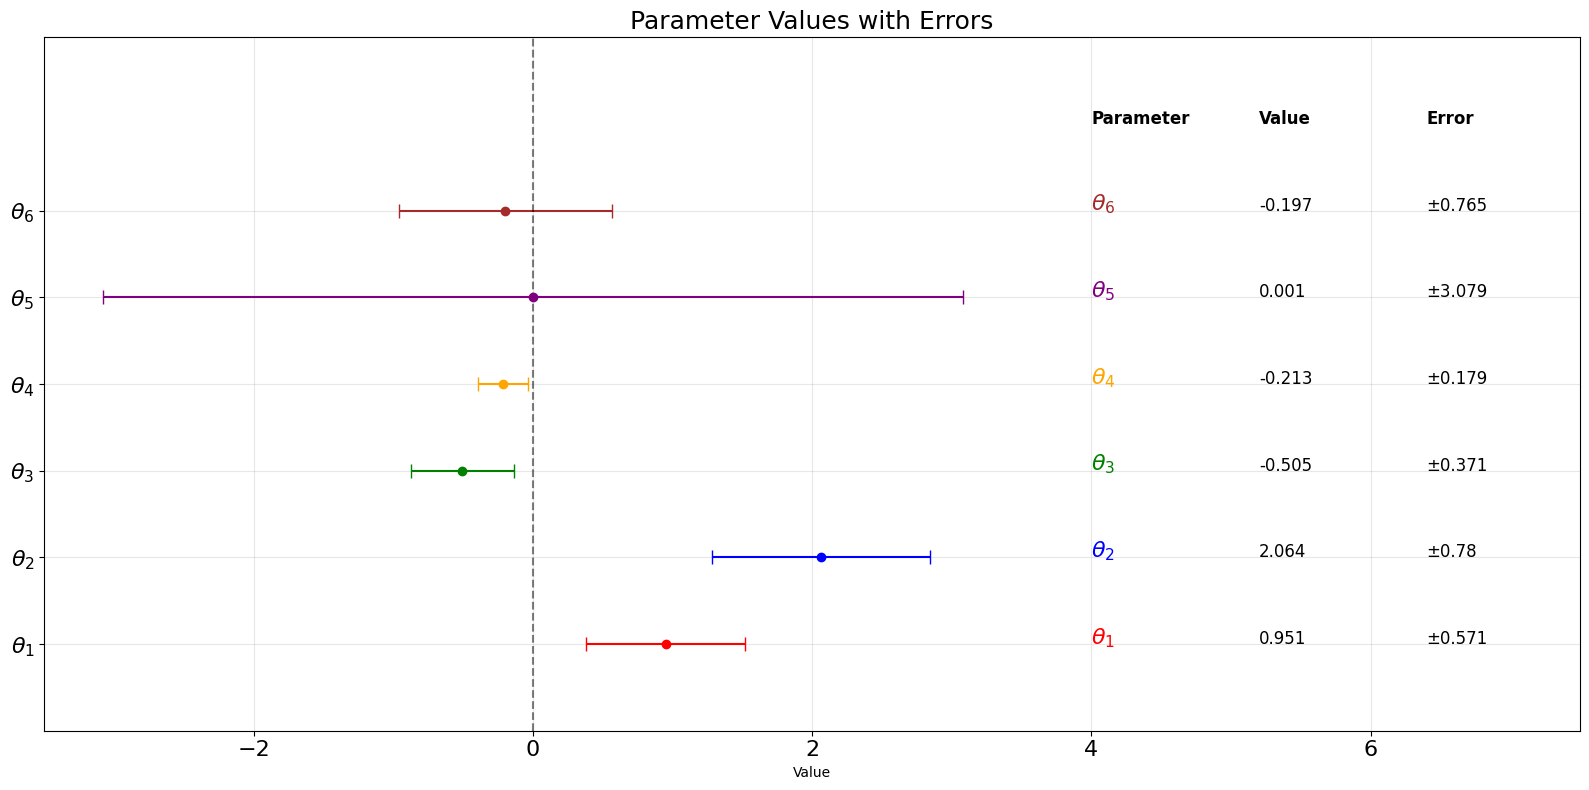

In [16]:
colours = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

fig, ax_plot = plt.subplots(figsize=(16, 8))

for i in range(len(values)):
    ax_plot.errorbar(
        y=i,
        x=values[i],
        xerr=errors[i],
        fmt='o',
        capsize=5,
        color=colours[i],
        label=f'theta_{i+1}'
    )

plt.xlim(-3.5, 7.5)  
plt.ylim(-1, len(values) + 1)
plt.tick_params(axis='both', labelsize=16)  
y_labels = [fr'$\theta_{i+1}$' for i in range(len(values))]
ax_plot.set_yticks(np.arange(len(values)))
ax_plot.set_yticklabels(y_labels)
ax_plot.set_xlabel('Value')
ax_plot.set_title('Parameter Values with Errors', fontsize = 18)
ax_plot.grid(True, alpha=0.3)
ax_plot.axvline(x=0, color='black', linestyle='--', alpha=0.5)


Results_reversed = Results.iloc[::-1].reset_index(drop=True)
colours_reversed = colours[::-1]

#table positioning
xlim = ax_plot.get_xlim()
table_x_start = xlim[1] - 3.5
table_x_end = xlim[1]

#table 
for idx, row in Results_reversed.iterrows():
    y_pos = len(values) - 1 - idx  # Reverse order to match plot
    ax_plot.text(table_x_start, y_pos, row['Parameter'], 
                color=colours_reversed[idx], fontsize=16, fontweight='bold')
    ax_plot.text(table_x_start + 1.2, y_pos, row['Value'], 
                color='black', fontsize=12)
    ax_plot.text(table_x_start + 2.4, y_pos, '±' + str(row['Error']), 
                color='black', fontsize=12)

ax_plot.text(table_x_start, len(values), 'Parameter', fontweight='bold', fontsize=12)
ax_plot.text(table_x_start + 1.2, len(values), 'Value', fontweight='bold', fontsize=12)
ax_plot.text(table_x_start + 2.4, len(values), 'Error', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()